In [2]:
import re
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import power_transform

from transformers import AutoTokenizer
from transformers import AutoConfig, AutoModel

def preprocessing(text):
    # p1
    text = re.sub('\r\n', ' [BR] ', text)
    text = re.sub(' +', ' ', text)
    text = text.strip()
    
    return text

In [3]:
data_path = '../../input/commonlit-evaluate-student-summaries'
# os.listdir(data_path)

In [4]:
prompts_df = pd.read_csv(f'{data_path}/prompts_train.csv')
summary_df = pd.read_csv(f'{data_path}/summaries_train.csv')
print(prompts_df.shape, summary_df.shape)
display(prompts_df)
display(summary_df.head(2))

df = summary_df.merge(prompts_df, on="prompt_id")
print(df.shape)
display(df.head(2))

(4, 4) (7165, 5)


,prompt_id,prompt_question,prompt_title,prompt_text
0,39c16e,Summarize at least 3 elements of an ideal trag...,On Tragedy,Chapter 13 \r\nAs the sequel to what has alrea...
1,3b9047,"In complete sentences, summarize the structure...",Egyptian Social Structure,Egyptian society was structured like a pyramid...
2,814d6b,Summarize how the Third Wave developed over su...,The Third Wave,Background \r\nThe Third Wave experiment took ...
3,ebad26,Summarize the various ways the factory would u...,Excerpt from The Jungle,"With one member trimming beef in a cannery, an..."


,student_id,prompt_id,text,content,wording
0,000e8c3c7ddb,814d6b,The third wave was an experimentto see how peo...,0.205683,0.380538
1,0020ae56ffbf,ebad26,They would rub it up with soda to make the sme...,-0.548304,0.506755


(7165, 8)


,student_id,prompt_id,text,content,wording,prompt_question,prompt_title,prompt_text
0,000e8c3c7ddb,814d6b,The third wave was an experimentto see how peo...,0.205683,0.380538,Summarize how the Third Wave developed over su...,The Third Wave,Background \r\nThe Third Wave experiment took ...
1,0070c9e7af47,814d6b,The Third Wave developed rapidly because the ...,3.272894,3.219757,Summarize how the Third Wave developed over su...,The Third Wave,Background \r\nThe Third Wave experiment took ...


In [5]:
df["student_id"].nunique()

7165

In [6]:
df["prompt_title"].unique()

array(['The Third Wave', 'Excerpt from The Jungle',
       'Egyptian Social Structure', 'On Tragedy'], dtype=object)

In [7]:
df["prompt_question"].unique()

array(['Summarize how the Third Wave developed over such a short period of time and why the experiment was ended.',
       'Summarize the various ways the factory would use or cover up spoiled meat. Cite evidence in your answer.',
       'In complete sentences, summarize the structure of the ancient Egyptian system of government. How were different social classes involved in this government? Cite evidence from the text.',
       'Summarize at least 3 elements of an ideal tragedy, as described by Aristotle.'],
      dtype=object)

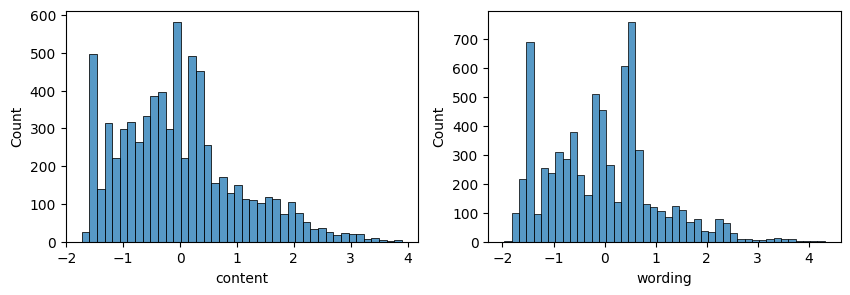

In [8]:
plot_cols = ["content", "wording"]

rows=1
cols=len(plot_cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))

for idx, col in enumerate(plot_cols):
    sns.histplot(x=col, data=df, ax=axes[idx])

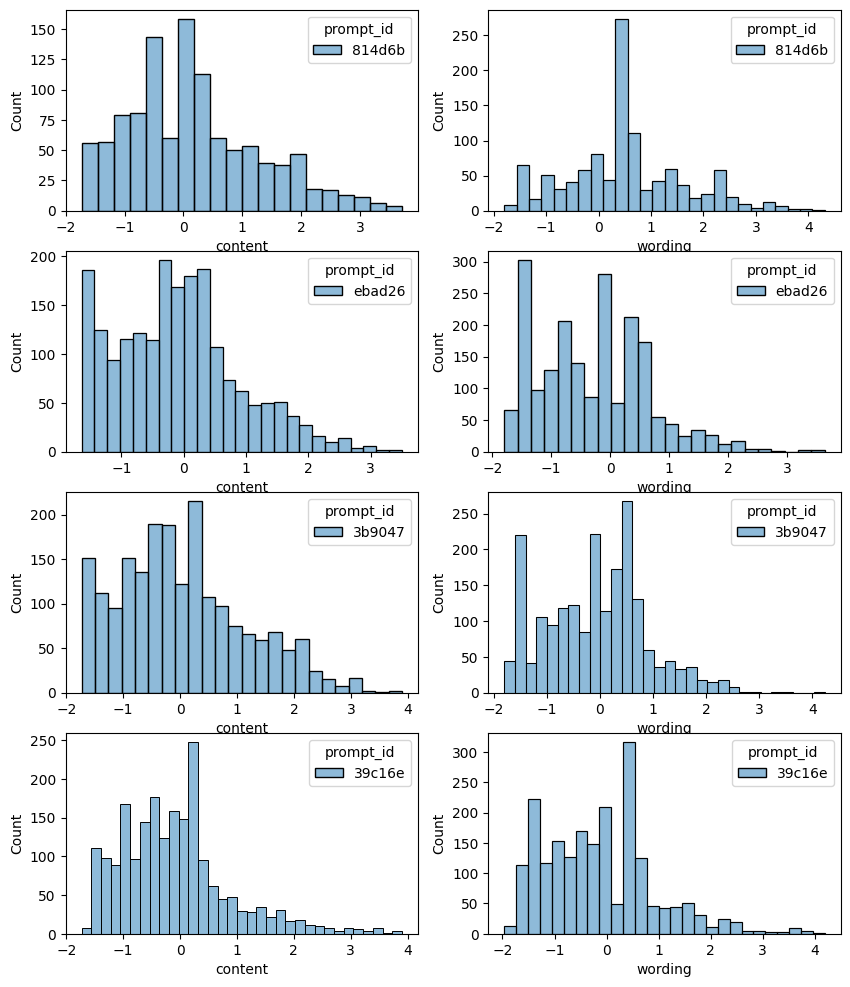

In [9]:
plot_cols = ["content", "wording"]

rows=df.prompt_id.nunique()
cols=len(plot_cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))

for row_idx, prompt_id  in enumerate(df.prompt_id.unique()):
    p_df = df[df['prompt_id']==prompt_id]
    for idx, col in enumerate(plot_cols):
        sns.histplot(x=col, data=p_df, ax=axes[row_idx, idx], hue="prompt_id")

In [10]:
df["prompt_text"].unique()

array(['Background \r\nThe Third Wave experiment took place at Cubberley High School in Palo Alto, California during the first week of April 1967. History teacher Ron Jones, finding himself unable to explain to his students how people throughout history followed the crowd even when terrible things were happening, decided to demonstrate it to his students through an experiment. Jones announced that he was starting a movement aimed to eliminate democracy. Jones named the movement “The Third Wave” as a symbol of strength, referring to the mythical belief that the third in a series of waves is the strongest. One of the central points of this movement was that democracy’s main weakness is that it favors the individual over the whole community. Jones emphasized this main point of the movement when he created this catchy motto: “Strength through discipline, strength through community, strength through action, strength through pride.” \r\nThe Experiment \r\nJones started the first day of the e

In [11]:
df['full_text'] = df["prompt_title"] + " " + df["prompt_text"]+ " " + df["prompt_question"]+ " " + df["text"]
df['full_text_processed'] =  df['full_text'].apply(lambda x: preprocessing(x))

df['full_text_len'] = df['full_text_processed'].apply(lambda x: len(x.split()))
df['unique_word_len'] = df['full_text_processed'].apply(lambda x: len(set(x.split())))

print(f"Min length in full text: {df['full_text_len'].min()}")
print(f"Max length in full text: {df['full_text_len'].max()}")
print(f"Number of samples longer than max length: {df[df['full_text_len']> 768].shape}")

Min length in full text: 620
Max length in full text: 1501
Number of samples longer than max length: (2332, 12)


In [12]:
plot_cols = ["content", "wording", "full_text_len", "unique_word_len"]

for col in plot_cols:
    df[f"{col}_log"] = np.log(df[col]+1)
    df[f"{col}_sqrt"] = np.sqrt(df[col])
    df[f"{col}_cbrt"] = np.cbrt(df[col])
    if col != "pixel_count":
        df[f"{col}_power"] = power_transform(df[col].values.reshape(-1, 1)).squeeze(-1)

/home/sthueva/anaconda3/envs/kaggle/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/sthueva/anaconda3/envs/kaggle/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/sthueva/anaconda3/envs/kaggle/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/sthueva/anaconda3/envs/kaggle/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


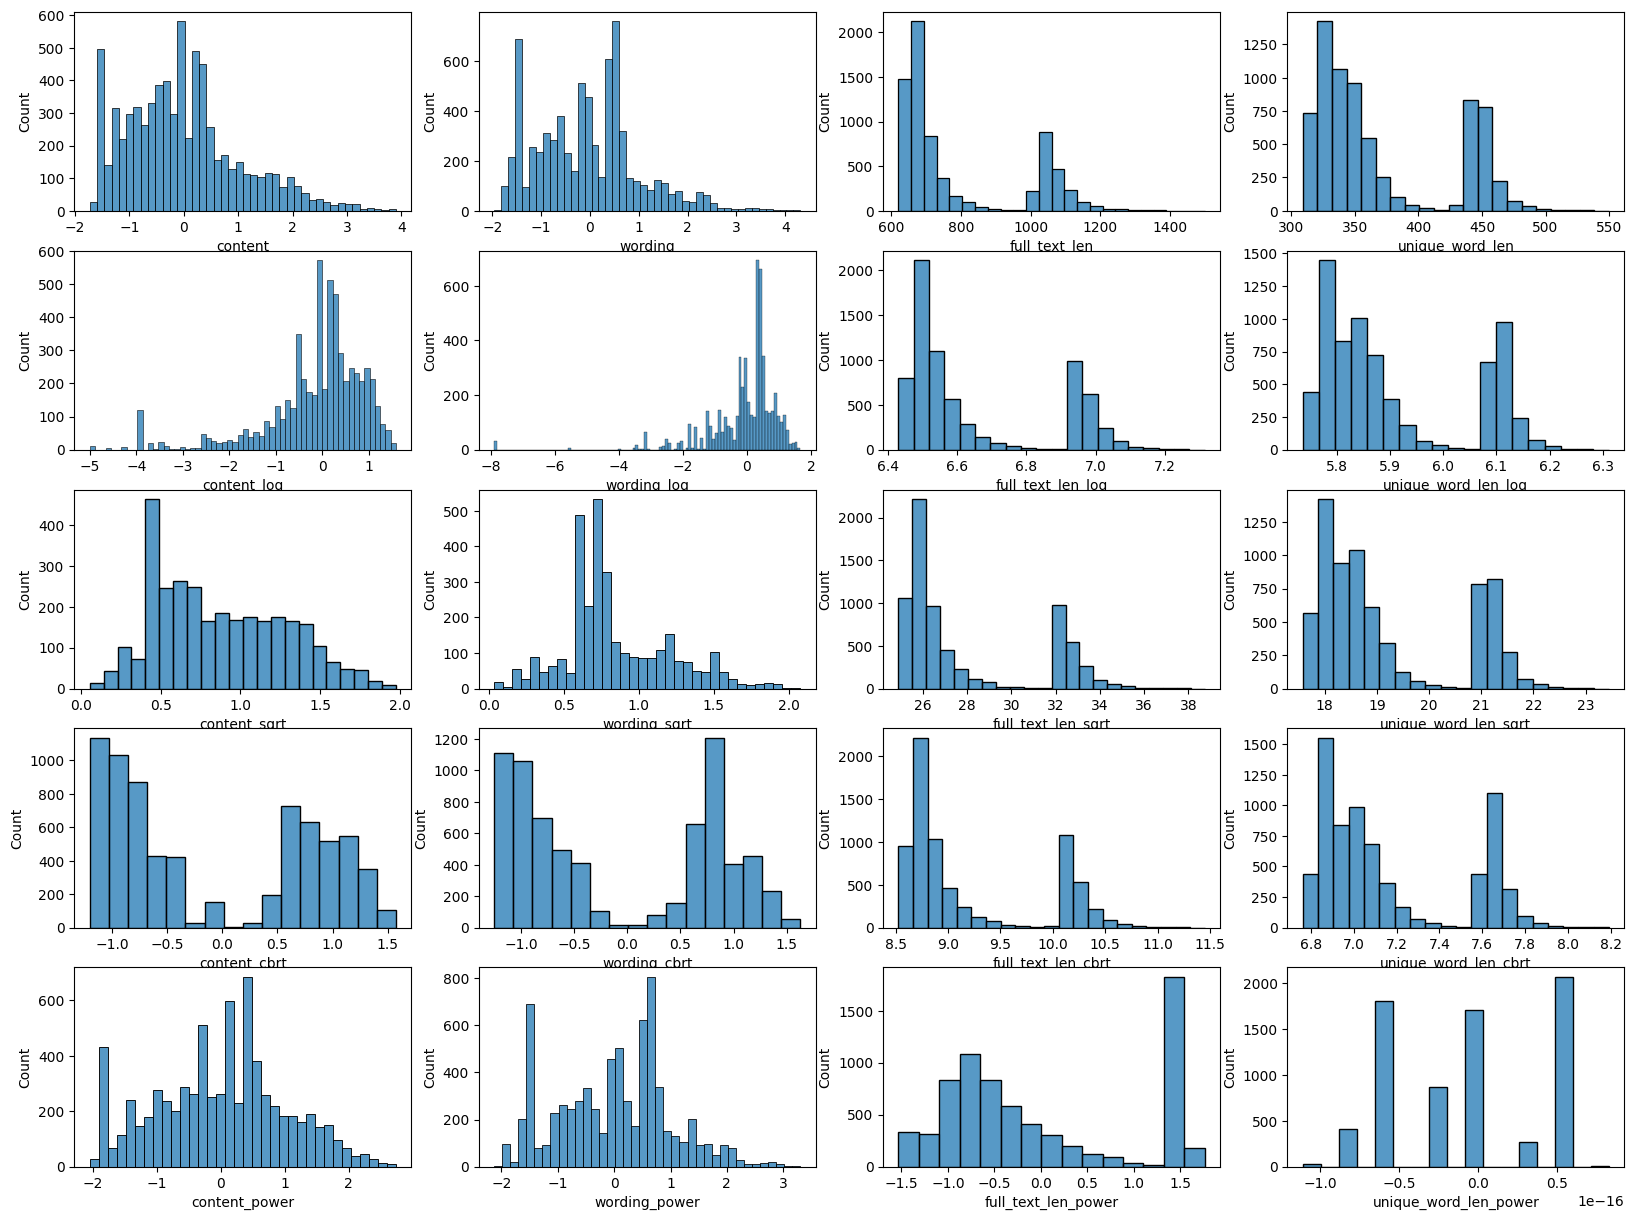

In [13]:
rows=5
cols=len(plot_cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))

for idx, col in enumerate(plot_cols):
    sns.histplot(x=col, data=df, ax=axes[0, idx])
    sns.histplot(x=f"{col}_log", data=df, ax=axes[1, idx])
    sns.histplot(x=f"{col}_sqrt", data=df, ax=axes[2, idx])
    sns.histplot(x=f"{col}_cbrt", data=df, ax=axes[3, idx])
    sns.histplot(x=f"{col}_power", data=df, ax=axes[4, idx])

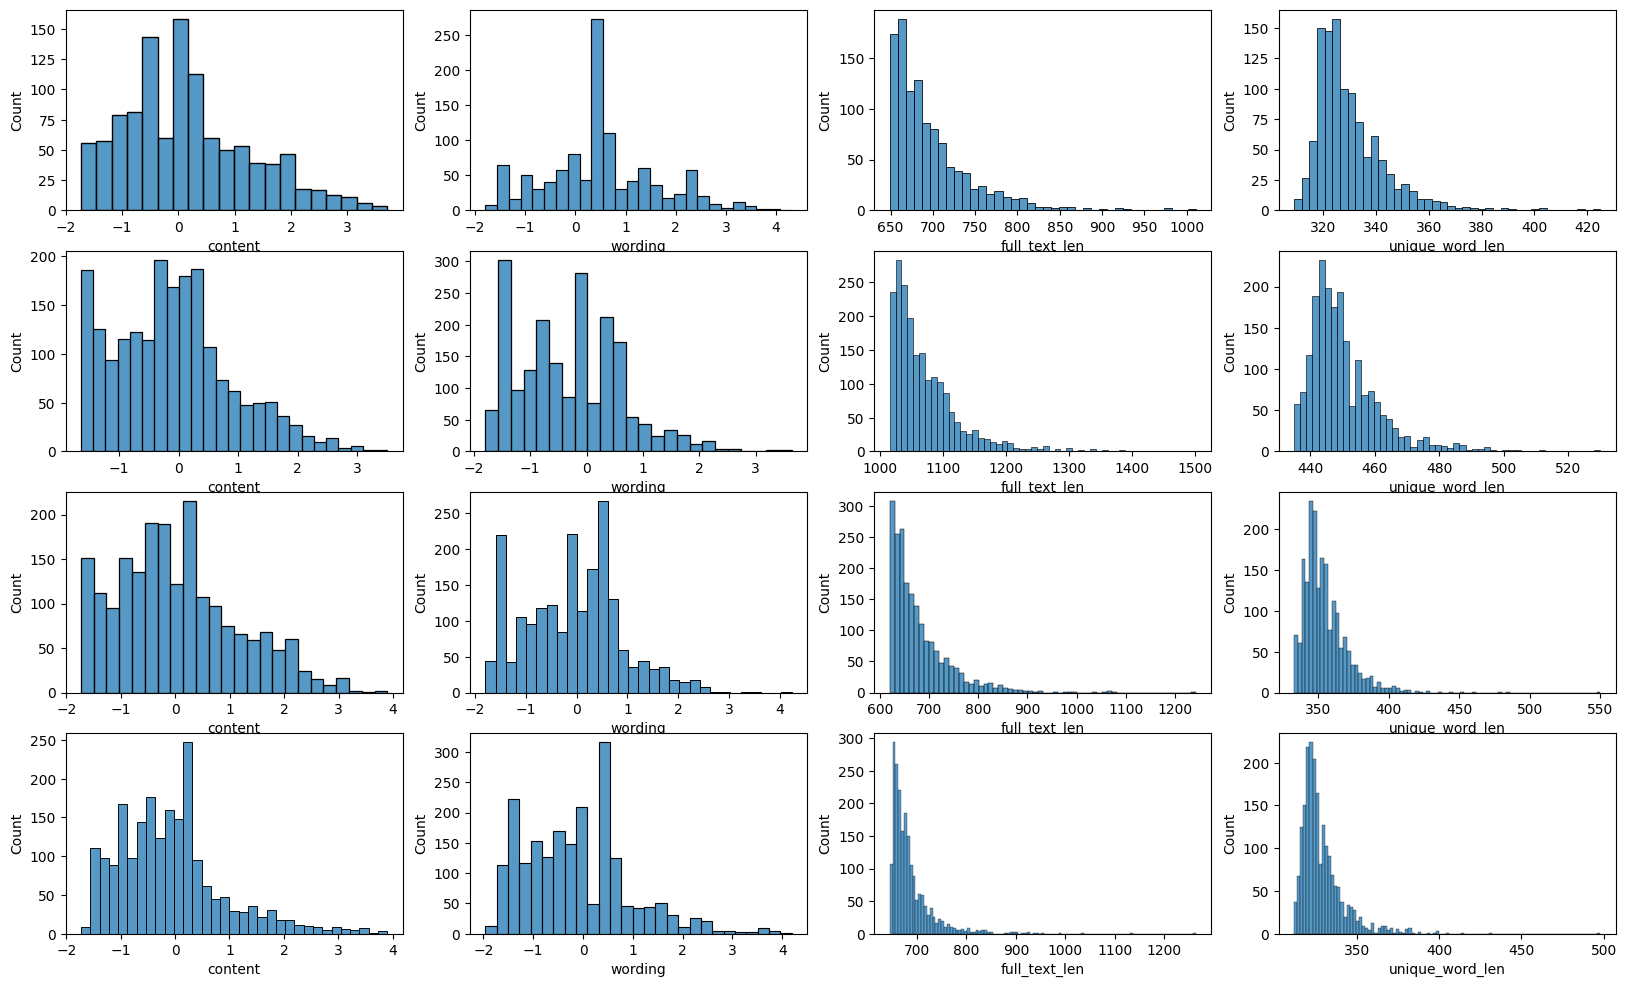

In [14]:
plot_cols = ["content", "wording", "full_text_len", "unique_word_len"]

rows=df.prompt_id.nunique()
cols=len(plot_cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))

for row_idx, prompt_id in enumerate(df.prompt_id.unique()):
    prom_df = df[df["prompt_id"] == prompt_id]
    for idx, col in enumerate(plot_cols):
        sns.histplot(x=col, data=prom_df, ax=axes[row_idx, idx])

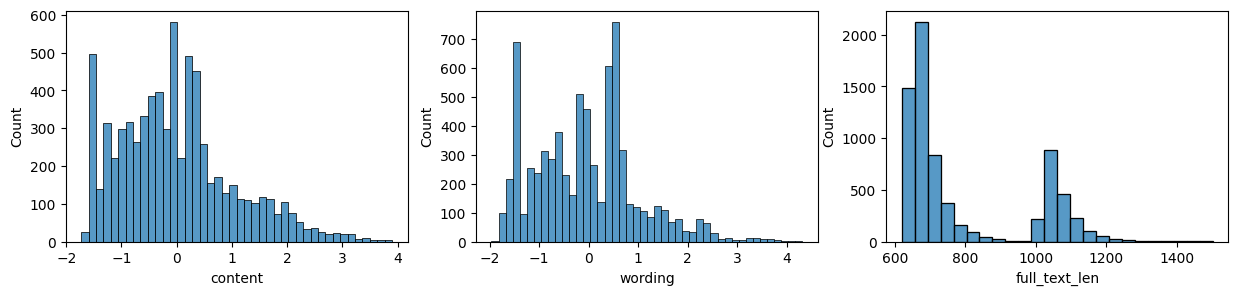

In [15]:
plot_cols = ["content", "wording", "full_text_len"]

rows=1
cols=len(plot_cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))

for idx, col in enumerate(plot_cols):
    sns.histplot(x=col, data=df, ax=axes[idx])

In [16]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/home/sthueva/anaconda3/envs/kaggle/lib/python3.9/site-packages/transformers/convert_slow_tokenizer.py:470: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [17]:
# tokenizer.add_special_tokens({'additional_special_tokens': ['[BR]', '[C]', '[W]']})

In [18]:
tokenizer.all_special_tokens

['[CLS]', '[SEP]', '[UNK]', '[PAD]', '[MASK]']

In [19]:
dir(tokenizer)

['SPECIAL_TOKENS_ATTRIBUTES',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_tokens',
 '_additional_special_tokens',
 '_auto_class',
 '_batch_encode_plus',
 '_bos_token',
 '_call_one',
 '_cls_token',
 '_convert_encoding',
 '_convert_id_to_token',
 '_convert_token_to_id_with_added_voc',
 '_create_repo',
 '_decode',
 '_decode_use_source_tokenizer',
 '_encode_plus',
 '_eos_token',
 '_eventual_warn_about_too_long_sequence',
 '_eventually_correct_t5_max_length',
 '_from_pretrained',
 '_get_files_timestamps',
 '_get_padding_truncation_strategies',
 '_in_target_context_manager',
 '_mask_token',
 '_pad',
 '_pad_token',
 '_pad

In [20]:
tokenizer.all_special_ids

[1, 2, 3, 0, 128000]

In [21]:
tokenizer.encode??


In [36]:
[9] * 4

[9, 9, 9, 9]

In [33]:
t = tokenizer(["[CLS][C][W]", 
               "[CLS] yes"],
            padding=True, 

             return_tensors='pt')

In [35]:
t['input_ids'].shape

torch.Size([2, 9])

In [7]:
tokenizer.tokenize("[CLS] content wording the text is perfect \n\n yes ")

['[CLS]',
 '▁content',
 '▁wording',
 '▁the',
 '▁text',
 '▁is',
 '▁perfect',
 '▁yes',
 '▁']

In [ ]:
tokenizer.tokenize("[CLS][C][W] the text is perfect")

In [36]:
tokenizer.tokenize(df.loc[0]["full_text_processed"])

['▁The',
 '▁Third',
 '▁Wave',
 '▁Background',
 '▁',
 '[BR]',
 '▁The',
 '▁Third',
 '▁Wave',
 '▁experiment',
 '▁took',
 '▁place',
 '▁at',
 '▁C',
 'ubber',
 'ley',
 '▁High',
 '▁School',
 '▁in',
 '▁Palo',
 '▁Alto',
 ',',
 '▁California',
 '▁during',
 '▁the',
 '▁first',
 '▁week',
 '▁of',
 '▁April',
 '▁1967',
 '.',
 '▁History',
 '▁teacher',
 '▁Ron',
 '▁Jones',
 ',',
 '▁finding',
 '▁himself',
 '▁unable',
 '▁to',
 '▁explain',
 '▁to',
 '▁his',
 '▁students',
 '▁how',
 '▁people',
 '▁throughout',
 '▁history',
 '▁followed',
 '▁the',
 '▁crowd',
 '▁even',
 '▁when',
 '▁terrible',
 '▁things',
 '▁were',
 '▁happening',
 ',',
 '▁decided',
 '▁to',
 '▁demonstrate',
 '▁it',
 '▁to',
 '▁his',
 '▁students',
 '▁through',
 '▁an',
 '▁experiment',
 '.',
 '▁Jones',
 '▁announced',
 '▁that',
 '▁he',
 '▁was',
 '▁starting',
 '▁a',
 '▁movement',
 '▁aimed',
 '▁to',
 '▁eliminate',
 '▁democracy',
 '.',
 '▁Jones',
 '▁named',
 '▁the',
 '▁movement',
 '▁“',
 'The',
 '▁Third',
 '▁Wave',
 '”',
 '▁as',
 '▁a',
 '▁symbol',
 '▁of',
 '

In [37]:
df["text"].unique()[0], df["content"].unique()[0], df["wording"].unique()[0]

('The third wave was an experimentto see how people reacted to a new one leader government. It gained popularity as people wanted to try new things. The students follow anything that is said and start turning on eachother to gain higher power. They had to stop the experement as too many people got to radical with it blindly following there leader',
 0.205682506482641,
 0.380537638762288)

In [22]:
df["text"].unique()[10],  df["content"].unique()[10], df["wording"].unique()[10]

('The Third Wave started off with the teacher giving small commands to the class to " eliminate democracy" but it was to really show that people follow what the crowd does. Soon as it moved on through the few days more commands were given and kids all over the school started to participate. The experiment was soon ended because Mr. Jones thought it was starting to get out  of hands, so he told everyone it was an experiment.',
 -1.26919628668938,
 0.474037870049486)

In [23]:
df["text"].unique()[100],  df["content"].unique()[100], df["wording"].unique()[100]

('The Third Wave developed over us a short period of time because  "Jones announced that they had been a part of an experiment to demonstrate how people willingly create a sense of superiority4 over others, and how this can lead people to justify doing horrible things in the name of the state’s honor."  As stated in paragraph 5.  This shows that Mr. Jones experiment worked out and he was able to prove his theory.',
 2.11352213681611,
 2.34269297501828)

In [15]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [33]:
s= df["prompt_text"][0].translate(str.maketrans('', '', string.punctuation))
s

'Background \r\nThe Third Wave experiment took place at Cubberley High School in Palo Alto California during the first week of April 1967 History teacher Ron Jones finding himself unable to explain to his students how people throughout history followed the crowd even when terrible things were happening decided to demonstrate it to his students through an experiment Jones announced that he was starting a movement aimed to eliminate democracy Jones named the movement “The Third Wave” as a symbol of strength referring to the mythical belief that the third in a series of waves is the strongest One of the central points of this movement was that democracy’s main weakness is that it favors the individual over the whole community Jones emphasized this main point of the movement when he created this catchy motto “Strength through discipline strength through community strength through action strength through pride” \r\nThe Experiment \r\nJones started the first day of the experiment emphasizing

In [40]:
pip install datasets

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 4.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.8/193.8 kB 6.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [41]:
from datasets import Dataset
train_set = Dataset.from_pandas(df)


In [42]:
train_set

Dataset({
    features: ['student_id', 'prompt_id', 'text', 'content', 'wording', 'prompt_question', 'prompt_title', 'prompt_text', 'full_text', 'full_text_processed', 'full_text_len', 'unique_word_len', 'content_log', 'content_sqrt', 'content_cbrt', 'content_power', 'wording_log', 'wording_sqrt', 'wording_cbrt', 'wording_power', 'full_text_len_log', 'full_text_len_sqrt', 'full_text_len_cbrt', 'full_text_len_power', 'unique_word_len_log', 'unique_word_len_sqrt', 'unique_word_len_cbrt', 'unique_word_len_power', '__index_level_0__'],
    num_rows: 7165
})

In [43]:
type(train_set)

datasets.arrow_dataset.Dataset

In [44]:
def preprocess(example):
    first_sentence = [example['prompt']] * 5
    second_sentences = [example[option] if example[option] is not None else '-' for option in 'ABCDE']
    tokenized_example = tokenizer(first_sentence, second_sentences, truncation=True)
    tokenized_example['label'] = option_to_index[example['answer']]
    
    return tokenized_example

In [45]:
train_dataset = train_set.map(preprocess, remove_columns=['prompt', 'A', 'B', 'C', 'D', 'E', 'answer'])

ValueError: Column to remove ['prompt', 'A', 'B', 'C', 'D', 'E', 'answer'] not in the dataset. Current columns in the dataset: ['student_id', 'prompt_id', 'text', 'content', 'wording', 'prompt_question', 'prompt_title', 'prompt_text', 'full_text', 'full_text_processed', 'full_text_len', 'unique_word_len', 'content_log', 'content_sqrt', 'content_cbrt', 'content_power', 'wording_log', 'wording_sqrt', 'wording_cbrt', 'wording_power', 'full_text_len_log', 'full_text_len_sqrt', 'full_text_len_cbrt', 'full_text_len_power', 'unique_word_len_log', 'unique_word_len_sqrt', 'unique_word_len_cbrt', 'unique_word_len_power', '__index_level_0__']